## User Study Analysis Notebook

Generates graphs from the user study data csv files collected

In [1]:
import matplotlib.pyplot as plt
import csv
import pandas
import seaborn
import numpy as np

## Look at survey

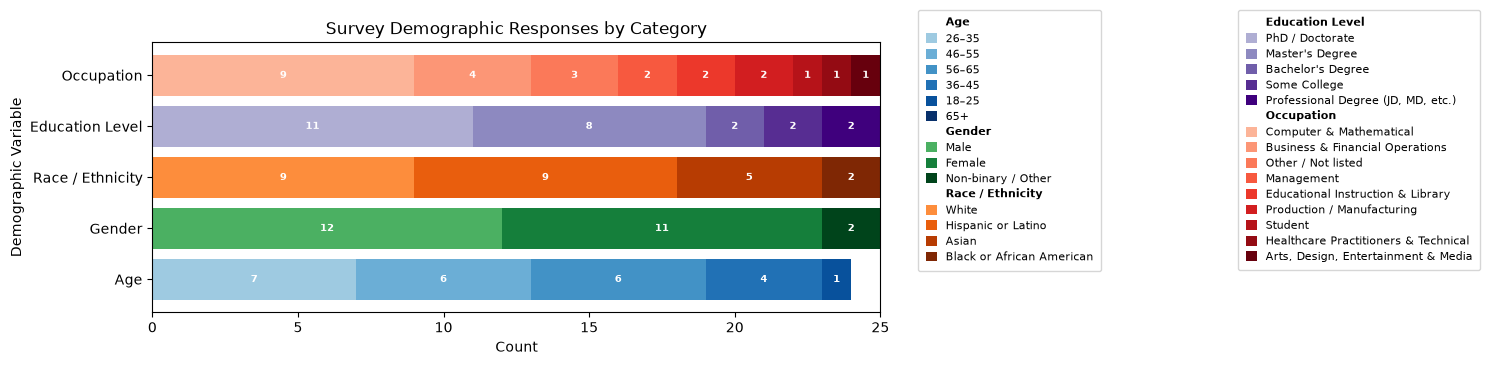

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.lines import Line2D

df = pd.read_csv("survey_responses.csv")

# Normalize Spanish-language responses to English equivalents
translations = {
    "gender":          {"Masculino": "Male"},
    "race_ethnicity":  {"Blanco": "White"},
    "education_level": {"Título profesional (JD, MD, etc.)": "Professional Degree (JD, MD, etc.)"},
    "occupation":      {"Operaciones comerciales y financieras": "Business & Financial Operations"},
}
for col, mapping in translations.items():
    df[col] = df[col].replace(mapping)

# Bin age into ranges
age_bins = [0, 25, 35, 45, 55, 65, 120]
age_labels = ["18–25", "26–35", "36–45", "46–55", "56–65", "65+"]
df["age_group"] = pd.cut(df["age"], bins=age_bins, labels=age_labels, right=True)

cols = {
    "Age":              "age_group",
    "Gender":           "gender",
    "Race / Ethnicity": "race_ethnicity",
    "Education Level":  "education_level",
    "Occupation":       "occupation",
}

# One colormap family per variable
cmap_names = ["Blues", "Greens", "Oranges", "Purples", "Reds"]
group_categories = {}
cat_color = {}

for (label, col), cmap_name in zip(cols.items(), cmap_names):
    cats = df[col].dropna().value_counts().index.tolist()
    group_categories[label] = cats
    cmap = plt.get_cmap(cmap_name, len(cats) + 3)
    for j, cat in enumerate(cats):
        cat_color[cat] = cmap(j + 3)

all_categories = [cat for label in cols for cat in group_categories[label]]

rows = {label: df[col].value_counts(dropna=True) for label, col in cols.items()}
stacked_df = pd.DataFrame(rows, index=all_categories).fillna(0).T

# Wide figure; right=0.58 leaves ~42% of width for the two legend columns
fig, ax = plt.subplots(figsize=(16, 3.5))
plt.subplots_adjust(right=0.58)

left = np.zeros(len(stacked_df))
for cat in all_categories:
    if cat in stacked_df.columns:
        values = stacked_df[cat].values
        bars = ax.barh(stacked_df.index, values, left=left, color=cat_color[cat])
        for bar, val, l in zip(bars, values, left):
            if val >= 1:
                ax.text(
                    l + val / 2, bar.get_y() + bar.get_height() / 2,
                    str(int(val)),
                    ha="center", va="center", fontsize=7.5,
                    color="white", fontweight="bold",
                )
        left += values

def build_legend_entries(labels):
    handles, texts = [], []
    for label in labels:
        handles.append(Line2D([], [], linestyle="None", linewidth=0))
        texts.append(f"$\\bf{{{label.replace(' ', '\\ ')}}}$")
        for cat in group_categories[label]:
            handles.append(mpatches.Patch(facecolor=cat_color[cat]))
            texts.append(str(cat))
    return handles, texts

legend_kwargs = dict(
    loc="upper left",
    bbox_transform=fig.transFigure,
    fontsize=8,
    handlelength=1,
    handleheight=1,
    borderpad=0.7,
    labelspacing=0.35,
    frameon=True,
)

# Left legend column: Age, Gender, Race / Ethnicity
h1, l1 = build_legend_entries(["Age", "Gender", "Race / Ethnicity"])
leg1 = ax.legend(h1, l1, bbox_to_anchor=(0.60, 0.99), **legend_kwargs)
ax.add_artist(leg1)

# Right legend column: Education Level, Occupation
h2, l2 = build_legend_entries(["Education Level", "Occupation"])
ax.legend(h2, l2, bbox_to_anchor=(0.80, 0.99), **legend_kwargs)

ax.set_xlabel("Count")
ax.set_ylabel("Demographic Variable")
ax.set_title("Survey Demographic Responses by Category")
plt.show()


### Calculate User accuracy by comparing

In [3]:
HIRING_THRESHOLD = 40
def hire_prob(qual_score):
    hiring_score = (qual_score+4+3+6)/2.5       # assume everyone is the advantage bias scenario: male, white, young
    p = 1 / (1 + np.exp(-(hiring_score - HIRING_THRESHOLD)/5))
    return p

In [4]:
for i in range(11):
    print(f"{i-5} -> {1 / (1 + np.exp(-(40+(i-5) - HIRING_THRESHOLD)/5))}")

-5 -> 0.2689414213699951
-4 -> 0.31002551887238755
-3 -> 0.35434369377420455
-2 -> 0.401312339887548
-1 -> 0.45016600268752216
0 -> 0.5
1 -> 0.549833997312478
2 -> 0.598687660112452
3 -> 0.6456563062257954
4 -> 0.6899744811276125
5 -> 0.7310585786300049


In [5]:
# true values of whether they should be hired
study_app = pd.read_csv("study_applicants.csv")

In [6]:
study_app["non_bias_qual_score"] = study_app["true_qualification"].apply(hire_prob)

In [7]:
study_app["should_be_hired"] = study_app["true_qualification"].apply(
    lambda x: int(hire_prob(x) > 0.5) if pd.notna(x) else 0
)
study_app

,id,name,gender,race,age,age_group,education_level,education_organization,years_experience,skills,languages,test_score,true_qualification,hiring_score,was_disadvantaged,disadvantage_reason,hired,non_bias_qual_score,should_be_hired
0,695,James Thornton,Male,White,34,Young,PhD,Elite University,11,Debugging; Docker; JavaScript; Data Structures...,English,82.96,79.11,36.84,1,NaN,0,0.347238,0
1,635,Michel Lefevre,Male,White,31,Young,Master,Online Institution,3,Debugging; Java; Teamwork,English; French; Arabic,85.44,82.18,38.07,0,NaN,1,0.404777,0
2,102,André Ferreira,Male,White,54,Older,Master,Online Institution,26,AWS; Git; Algorithms; Python; Problem Solving,English; Portuguese,89.58,91.81,31.52,1,age,0,0.595030,1
3,904,Robert Mitchell,Male,White,64,Older,PhD,Public University,25,Docker; Python; Teamwork; Git,English,59.41,87.60,29.84,0,NaN,1,0.511998,1
4,3,David Anderson,Male,White,46,Middle,High School,Private High School,10,AWS; Data Structures; Git; Python,English,53.82,64.44,28.58,1,NaN,0,0.141268,0
5,799,Thomas Harrington,Male,White,49,Middle,Bachelor,Public University,16,Debugging; Problem Solving; Docker; Communicat...,English; Mandarin; Arabic,85.35,94.61,40.64,0,NaN,1,0.647667,1
6,843,Liang Silva,Male,Other,33,Young,Bachelor,Online Institution,3,Data Structures; Machine Learning; Communicati...,English; Mandarin; Portuguese,69.20,55.41,23.36,1,race,0,0.073973,0
7,646,Omar Ramos,Male,Other,25,Young,Master,Public University,3,Java; Communication; Machine Learning; Algorit...,English; Arabic; Spanish,74.26,79.43,32.97,0,NaN,1,0.353064,0
8,520,Marcus Johnson,Male,Other,63,Older,Bachelor,Public University,24,Data Structures; Java; Docker; SQL; Python,English,66.53,78.82,22.33,1,race; age,0,0.341999,0
9,536,Davi Alves,Male,Other,60,Older,High School,Private High School,14,Data Structures; SQL; Problem Solving; Machine...,English; Portuguese,71.81,80.65,23.06,0,NaN,1,0.375662,0


In [8]:
import pandas as pd

votes = pd.read_csv("votes.csv")

# Aggregate per applicant; exclude IDs with only 1 vote (incomplete/test sessions)
agg = (
    votes.groupby("applicant_id")["hired"]
    .agg(votes="count", avg_hire_rate="mean")
    .reset_index()
)
agg = agg[agg["votes"] > 1].sort_values("avg_hire_rate", ascending=False).reset_index(drop=True)
agg.index += 1  # rank starting at 1
agg["avg_hire_rate"] = agg["avg_hire_rate"].round(3)
agg.columns = ["Applicant ID", "# Votes", "Avg Hire Rate"]


In [9]:
app_info = study_app[['id', 'name', 'gender', 'race', 'age', 'should_be_hired', 'hired']].drop_duplicates(subset='id')
agg_with_meta = agg.merge(app_info, left_on='Applicant ID', right_on='id', how='left')

agg_with_meta = agg_with_meta[
    ['Applicant ID', 'name', 'gender', 'race', 'age', 'should_be_hired', 'hired','# Votes', 'Avg Hire Rate']
].rename(
    columns={
        'name': 'Name',
        'gender': 'Gender',
        'race': 'Race',
        'age': 'Age',
        'should_be_hired': 'Should Hire',
        'hired': "Was Hired"
    }
)

agg_with_meta.style \
    .background_gradient(subset=['Avg Hire Rate'], cmap='RdYlGn', vmin=0, vmax=1) \
    .format({'Avg Hire Rate': '{:.1%}'}) \
    .set_caption('Average hire rate per applicant with demographic metadata')

,Applicant ID,Name,Gender,Race,Age,Should Hire,Was Hired,# Votes,Avg Hire Rate
0,844,Jennifer Hartley,Female,White,47,0,0,20,85.0%
1,695,James Thornton,Male,White,34,0,0,18,83.3%
2,57,Amélie Fontaine,Female,White,65,1,1,18,83.3%
3,102,André Ferreira,Male,White,54,1,0,18,83.3%
4,487,Mateus Costa,Male,Other,47,1,0,16,81.2%
5,799,Thomas Harrington,Male,White,49,1,1,19,78.9%
6,536,Davi Alves,Male,Other,60,0,1,19,78.9%
7,525,Amara Diallo,Female,Other,30,1,1,17,76.5%
8,646,Omar Ramos,Male,Other,25,0,1,17,76.5%
9,336,Yasmine Torres,Female,Other,43,0,0,19,73.7%


In [10]:
# show table grouped by 'Should Hire' with True first
grouped = agg_with_meta.sort_values("Should Hire", ascending=False)[
    ["Applicant ID", "Name", "Gender", "Race", "Age", "Should Hire", 'Was Hired', "# Votes", "Avg Hire Rate"]
]

grouped.style \
    .background_gradient(subset=["Avg Hire Rate"], cmap="RdYlGn", vmin=0, vmax=1) \
    .format({"Avg Hire Rate": "{:.1%}"}) \
    .set_caption("Applicants grouped by 'Should Hire' (True first)")

,Applicant ID,Name,Gender,Race,Age,Should Hire,Was Hired,# Votes,Avg Hire Rate
2,57,Amélie Fontaine,Female,White,65,1,1,18,83.3%
3,102,André Ferreira,Male,White,54,1,0,18,83.3%
4,487,Mateus Costa,Male,Other,47,1,0,16,81.2%
5,799,Thomas Harrington,Male,White,49,1,1,19,78.9%
7,525,Amara Diallo,Female,Other,30,1,1,17,76.5%
18,904,Robert Mitchell,Male,White,64,1,1,19,52.6%
14,6,François Zhao,Male,Other,49,1,1,16,62.5%
0,844,Jennifer Hartley,Female,White,47,0,0,20,85.0%
15,100000,Jade Nguyen,Female,Other,65,0,1,17,58.8%
22,843,Liang Silva,Male,Other,33,0,0,21,38.1%


In [11]:
def disadvantaged_group(row):
    parts = []
    if row["Age"] > 50:
        parts.append("Age > 50")
    if row["Gender"] == "Female":
        parts.append("Female")
    if row["Race"] == "Other":
        parts.append("Other race")
    return " + ".join(parts) if parts else "None"

agg_with_meta["Disadvantaged Group"] = agg_with_meta.apply(disadvantaged_group, axis=1)

group_order = [
    "Age > 50 + Female + Other race",
    "Age > 50 + Female",
    "Age > 50 + Other race",
    "Female + Other race",
    "Age > 50",
    "Female",
    "Other race",
    "None",
]
agg_with_meta["group_order"] = agg_with_meta["Disadvantaged Group"].map(
    {group: idx for idx, group in enumerate(group_order)}
).fillna(len(group_order))

agg_with_meta_sorted = agg_with_meta.sort_values(
    ["group_order", "Avg Hire Rate"], ascending=[True, False]
)[
    ["Applicant ID", "Name", "Gender", "Race", "Age", "Disadvantaged Group", 'Should Hire','Was Hired', "# Votes", "Avg Hire Rate"]
]

agg_with_meta_sorted.style \
    .background_gradient(subset=["Avg Hire Rate"], cmap="RdYlGn", vmin=0, vmax=1) \
    .format({"Avg Hire Rate": "{:.1%}"}) \
    .set_caption("Average hire rate per applicant, ordered with disadvantaged groups first")

,Applicant ID,Name,Gender,Race,Age,Disadvantaged Group,Should Hire,Was Hired,# Votes,Avg Hire Rate
13,737,Ling Wu,Female,Other,59,Age > 50 + Female + Other race,0,0,19,68.4%
15,100000,Jade Nguyen,Female,Other,65,Age > 50 + Female + Other race,0,1,17,58.8%
2,57,Amélie Fontaine,Female,White,65,Age > 50 + Female,1,1,18,83.3%
17,964,Isabella García,Female,White,57,Age > 50 + Female,0,0,22,54.5%
6,536,Davi Alves,Male,Other,60,Age > 50 + Other race,0,1,19,78.9%
16,520,Marcus Johnson,Male,Other,63,Age > 50 + Other race,0,0,19,57.9%
7,525,Amara Diallo,Female,Other,30,Female + Other race,1,1,17,76.5%
9,336,Yasmine Torres,Female,Other,43,Female + Other race,0,0,19,73.7%
11,108,Mei Reyes,Female,Other,25,Female + Other race,0,0,20,70.0%
20,397,Nadia Okonkwo,Female,Other,38,Female + Other race,0,1,17,41.2%


### Matrices

In [12]:
confusion = pd.crosstab(
    agg_with_meta["Should Hire"],
    agg_with_meta["Was Hired"],
    rownames=["Should Hire"],
    colnames=["Was Hired"],
)

confusion.index = ["Shouldn't Hire", "Should Hire"]
confusion.columns = ["Not Hired", "Hired"]

confusion

,Not Hired,Hired
Shouldn't Hire,10,7
Should Hire,2,5


In [13]:
predicted = agg_with_meta["Avg Hire Rate"] > 0.5

confusion_avg_rate = pd.crosstab(
    predicted.map({False: "Not Predicted Hired", True: "Predicted Hired"}),
    agg_with_meta["Was Hired"].map({0: "Not Hired", 1: "Hired"}),
    rownames=["Prediction"],
    colnames=["Actual"],
)

confusion_avg_rate

Actual,Hired,Not Hired
Prediction,,
Not Predicted Hired,3,2
Predicted Hired,9,10
